# **Импорты**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from tensorflow.keras.preprocessing import image  # для загрузки своего фото
import gdown
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


# **Загрузка MNIST**

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),  # преобразует PIL Image в тензор и нормирует в [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # стандартная нормализация для MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 63.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.63MB/s]


# **Определение модели**

In [3]:
class UltraNet(nn.Module):
    def __init__(self):
        super(UltraNet, self).__init__()
        self.fc1 = nn.Linear(28*28, 800)
        self.fc2 = nn.Linear(800, 400)
        self.fc3 = nn.Linear(400, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)  # flatten
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = UltraNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Обучение**

In [4]:
num_epochs = 15
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    # Оценка на тесте после каждой эпохи
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    test_acc = correct / total
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}, Test Acc: {test_acc:.4f}")

# Сохраняем веса
torch.save(model.state_dict(), 'mnist_weights.weights.pt')
print("✅ Веса сохранены в 'mnist_weights.weights.pt'")

Epoch 1, Loss: 0.2095, Test Acc: 0.9699
Epoch 2, Loss: 0.0832, Test Acc: 0.9720
Epoch 3, Loss: 0.0567, Test Acc: 0.9773
Epoch 4, Loss: 0.0431, Test Acc: 0.9807
Epoch 5, Loss: 0.0328, Test Acc: 0.9772
Epoch 6, Loss: 0.0272, Test Acc: 0.9796
Epoch 7, Loss: 0.0253, Test Acc: 0.9816
Epoch 8, Loss: 0.0229, Test Acc: 0.9743
Epoch 9, Loss: 0.0187, Test Acc: 0.9785
Epoch 10, Loss: 0.0159, Test Acc: 0.9813
Epoch 11, Loss: 0.0175, Test Acc: 0.9782
Epoch 12, Loss: 0.0172, Test Acc: 0.9830
Epoch 13, Loss: 0.0122, Test Acc: 0.9798
Epoch 14, Loss: 0.0137, Test Acc: 0.9769
Epoch 15, Loss: 0.0144, Test Acc: 0.9841
✅ Веса сохранены в 'mnist_weights.weights.pt'


# **Загрузка пользовательского изображения**


📸 Загрузите фотографию своей рукописной цифры.


Saving цифра.png to цифра.png
Загружен файл: цифра.png


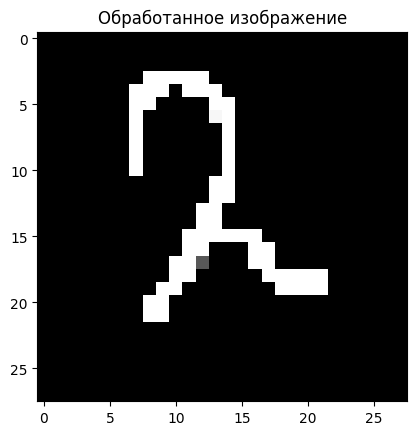

In [5]:
# Загрузка
print("\n📸 Загрузите фотографию своей рукописной цифры.")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"Загружен файл: {filename}")

# Загрузка и предобработка изображения
img = image.load_img(filename, target_size=(28, 28), color_mode='grayscale')
img_array = image.img_to_array(img)  # (28,28,1)

# Инверсия (если фон светлый, цифра тёмная)
img_array = 255.0 - img_array

# Нормализация в [0,1]
img_array = img_array / 255.0

# Убираем канал и reshape для модели
img_vector = img_array.reshape(1, -1)  # (1, 784)

# Преобразуем в тензор и применяем ту же нормализацию, что для MNIST
img_tensor = torch.tensor(img_vector, dtype=torch.float32)
# Стандартизация: (x - mean) / std  (mean=0.1307, std=0.3081)
img_tensor = (img_tensor - 0.1307) / 0.3081
img_tensor = img_tensor.to(device)

# Покажем обработанное изображение
plt.imshow(img_array.reshape(28,28), cmap='gray')
plt.title("Обработанное изображение")
plt.show()

# **Предсказание**

In [6]:
model.eval()
with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
    pred = np.argmax(probs)

print(f"\n🎯 Нейросеть распознала цифру: {pred}")
print("Вероятности по классам:")
for i, p in enumerate(probs):
    print(f"  {i}: {p:.4f}")


🎯 Нейросеть распознала цифру: 2
Вероятности по классам:
  0: 0.0000
  1: 0.0000
  2: 1.0000
  3: 0.0000
  4: 0.0000
  5: 0.0000
  6: 0.0000
  7: 0.0000
  8: 0.0000
  9: 0.0000
